In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Новости по каждой компании

In [2]:
sber_news = pd.read_csv('Sber_news_last.csv')
sber_news['Company'] = ['sber' for i in range(len(sber_news))]
lukoil_news = pd.read_csv('lukoil_news_last_1.csv')
lukoil_news['Company'] = ['lukoil' for i in range(len(lukoil_news))]
nlmk_news = pd.read_csv('nlmk_news_last.csv')
nlmk_news['Company'] = ['nlmk' for i in range(len(nlmk_news))]
magnit_news = pd.read_csv('magnit_news_last.csv')
magnit_news['Company'] = ['magnit' for i in range(len(magnit_news))]
positiv_news = pd.read_csv('positive_tech_news_last.csv')
positiv_news['Company'] = ['positiv' for i in range(len(positiv_news))]

### Все новости

In [3]:
all_news = pd.concat([sber_news, lukoil_news, nlmk_news, magnit_news, positiv_news])

In [4]:
all_news['News_released'] = all_news['News_released'].apply(lambda x: x.split()[0])
all_news.rename(columns = {'News_released': 'Date'}, inplace = True) 
all_news['Date'] = pd.to_datetime(all_news['Date'], format='%d.%m.%Y') # переведем все в datetime, чтобы работать как с дата объектом 
all_news = all_news.groupby(['Date', 'Company']).agg({'Header': ' '.join, 'Full_news': ' '.join}).reset_index()
all_news = all_news.sort_values(by = 'Date', ascending = False)

In [5]:
all_news

,Date,Company,Header,Full_news
2829,2024-12-23,magnit,Приобретение подконтрольной эмитенту организац...,Сообщение о существенном факте\nо приобретении...
2828,2024-12-20,positiv,Совершение эмитентом существенной сделки,Совершение эмитентом существенной сделки\n\n1....
2827,2024-12-20,lukoil,Проведение заседания совета директоров (наблюд...,СООБЩЕНИЕ О СУЩЕСТВЕННОМ ФАКТЕ\n О ПРОВЕДЕНИИ ...
2826,2024-12-19,positiv,Решения единственного акционера (участника),Решения единственного акционера (участника)\n\...
2825,2024-12-19,magnit,"Выплаченные доходы или иные выплаты, причитающ...",Сообщение\nо выплаченных доходах по ценным бум...
...,...,...,...,...
5,2018-01-10,sber,Выплаченные доходы по эмиссионным ценным бумаг...,СООБЩЕНИЕ о существенном факте \n«О выплаченны...
3,2018-01-08,sber,Дата начала размещения ценных бумаг Утверждени...,СООБЩЕНИЕ \nо дате начала размещения ценных бу...
2,2018-01-06,lukoil,"Сведения, направленные за пределы РФ для их ра...","Сообщение о существенном факте\nо сведениях, н..."
1,2018-01-03,lukoil,"Сведения, направленные за пределы РФ для их ра...","Сообщение о существенном факте\nо сведениях, н..."


### Токенизация 

In [173]:
import re

def tokenise(s):
    # Убираем пробелы внутри чисел (например, 10 000 000 → 10000000)
    s = re.sub(r'(?<=\d) (?=\d)', '', s)

    # Заменяем все вещественные числа и проценты на маркеры
    s_with_marks = re.sub(r'\d+\.\d+%', lambda m: f'PERCENT{m.group(0)}__', s)
    s_with_marks = re.sub(r'\d+\.\d+', lambda m: f'FLOAT{m.group(0)}__', s_with_marks)

    # Группируем "руб." с предыдущим числом или словом
    s_with_marks = re.sub(r'(\S+) (руб\.)', r'\1\2', s_with_marks)

    # Убираем запятые, если они не являются частью числа (например, "1,234" должно остаться)
    s_with_marks = re.sub(r'(?<!\d),(?!\d)', '', s_with_marks)

    # Разделяем строку по пробелам, знакам препинания (кроме точек в числах и процентах)
    parts = re.split(r'[^a-zA-Zа-яА-Я0-9.%]+', s_with_marks)

    # Убираем одинокие знаки препинания и точки в конце слов (если они не в числе/проценте)
    result = [
        re.sub(r'\.(?=$|[^0-9])', '', part.replace('FLOAT', '').replace('PERCENT', ''))
        for part in parts
        if part and not re.fullmatch(r'[.,%]+', part)
    ]

    # Восстанавливаем "не " перед словами
    cleaned_result = []
    i = 0
    while i < len(result):
        if result[i] == "не" and i + 1 < len(result):
            cleaned_result.append("не " + result[i + 1])
            i += 2  # Пропускаем следующее слово, так как уже объединили
        else:
            cleaned_result.append(result[i])
            i += 1

    # Фильтруем слова:
    final_result = [
        word for word in cleaned_result
        if "ru" not in word.lower()                 # Убираем слова с "ru"
        and "www" not in word.lower()               # Убираем слова с "www"
        and not re.search(r'\d+b', word.lower())    # Убираем облигации (например, "10b")
        and not re.search(r'\d+[a-zA-Z]+', word)    # Убираем смешанные слова (например, "4b0215401481b001p")
    ]

    return final_result

In [177]:
all_news['Full_news'] = all_news['Full_news'].apply(lambda x: tokenise(str(x).lower()))
all_news.head()

,Date,Company,Header,Full_news
2829,2024-12-23,magnit,Приобретение подконтрольной эмитенту организац...,"[сообщение, о, существенном, факте, о, приобре..."
2828,2024-12-20,positiv,Совершение эмитентом существенной сделки,"[совершение, эмитентом, существенной, сделки, ..."
2827,2024-12-20,lukoil,Проведение заседания совета директоров (наблюд...,"[сообщение, о, существенном, факте, о, проведе..."
2826,2024-12-19,positiv,Решения единственного акционера (участника),"[решения, единственного, акционера, участника,..."
2825,2024-12-19,magnit,"Выплаченные доходы или иные выплаты, причитающ...","[сообщение, о, выплаченных, доходах, по, ценны..."


### Лемматизация

In [178]:
import nltk
from nltk import WordNetLemmatizer
import pymorphy3
morph = pymorphy3.MorphAnalyzer()

In [179]:
def lemmatizing(tokenized_text):
    text = [morph.parse(word)[0].normal_form for word in tokenized_text]
    return text

all_news['Full_news'] = all_news['Full_news'].apply(lambda x: lemmatizing(x))
all_news.head()

,Date,Company,Header,Full_news
2829,2024-12-23,magnit,Приобретение подконтрольной эмитенту организац...,"[сообщение, о, существенный, факт, о, приобрет..."
2828,2024-12-20,positiv,Совершение эмитентом существенной сделки,"[совершение, эмитент, существенный, сделка, 1,..."
2827,2024-12-20,lukoil,Проведение заседания совета директоров (наблюд...,"[сообщение, о, существенный, факт, о, проведен..."
2826,2024-12-19,positiv,Решения единственного акционера (участника),"[решение, единственный, акционер, участник, 1,..."
2825,2024-12-19,magnit,"Выплаченные доходы или иные выплаты, причитающ...","[сообщение, о, выплатить, доход, по, ценный, б..."


### Стоп слова

In [181]:
import nltk

nltk.download('stopwords')
stopword = nltk.corpus.stopwords.words('russian')
stopword_new = ['сообщение', 'иных', 'существенное', 'существенный', 'факт','событие', 'влияние', 'существенном', 'действие', 'факте', 'протокол',
               'орган', ',', 'выпуск', 'ru', 'номер', 'bsk', 'prt', 'далее', 'серия', 'b', 't', '4b02', 'prt', 'www', '401481в001p02e',
               '5y', 'категория', 'isin', 'http', '001р', 'mem', 'мнение', 'кворум', 'имелся','запятая',
               'пао', 'fix', 'федерация', 'должный', 'фирменный', 'страница', 'признак', 'указанный', 'иос', 'адрес', 'форма', 'инна', 'иной', 'г']
stopword.extend(stopword_new)
stopword.remove('не')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [182]:
def remove_stopwords(tokenised_list):
    text = [word for word in tokenised_list if word not in stopword]
    return text

all_news['Full_news'] = all_news['Full_news'].apply(lambda x: remove_stopwords(x))
all_news.head()

,Date,Company,Header,Full_news
2829,2024-12-23,magnit,Приобретение подконтрольной эмитенту организац...,"[приобретение, голосовать, акция, доля, эмитен..."
2828,2024-12-20,positiv,Совершение эмитентом существенной сделки,"[совершение, эмитент, сделка, 1, общий, сведен..."
2827,2024-12-20,lukoil,Проведение заседания совета директоров (наблюд...,"[проведение, заседание, совет, директор, эмите..."
2826,2024-12-19,positiv,Решения единственного акционера (участника),"[решение, единственный, акционер, участник, 1,..."
2825,2024-12-19,magnit,"Выплаченные доходы или иные выплаты, причитающ...","[выплатить, доход, ценный, бумага, эмитент, та..."


### Сделали разделение с исключением 20% самых часто встречающихся слов

In [183]:
all_news['Full_news'] = all_news['Full_news'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

In [185]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Создаем TF-IDF векторизатор (удаляем редкие и частые слова)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(all_news['Full_news'])

# Получаем список оставшихся слов/фраз
remaining_words = set(vectorizer.get_feature_names_out())

# Фильтруем тексты: удаляем слова, не попавшие в TF-IDF
def filter_text(text):
    words = text.split()  # Разбиваем текст на слова
    filtered_words = [word for word in words if word in remaining_words]  # Оставляем только нужные слова
    return ' '.join(filtered_words)  # Собираем обратно

all_news['filtered_text'] = all_news['Full_news'].apply(filter_text)

### Все котировки акций

In [32]:
sber_stocks = pd.read_csv('Прошлые данные - SBER.csv')
sber_stocks['Company'] = ['sber' for i in range(len(sber_stocks))]
lukoil_stocks = pd.read_csv("Прошлые данные - LKOH.csv")
lukoil_stocks['Company'] = ['lukoil' for i in range(len(lukoil_stocks))]
nlmk_stocks = pd.read_csv("Прошлые данные - NLMK.csv")
nlmk_stocks['Company'] = ['nlmk' for i in range(len(nlmk_stocks))]
magnit_stocks = pd.read_csv("Прошлые данные - MGNT.csv")
magnit_stocks['Company'] = ['magnit' for i in range(len(magnit_stocks))]
positiv_stocks = pd.read_csv("Прошлые данные - POSI.csv")
positiv_stocks['Company'] = ['positiv' for i in range(len(positiv_stocks))]

In [33]:
all_stocks = pd.concat([sber_stocks, lukoil_stocks, nlmk_stocks, magnit_stocks, positiv_stocks])

In [34]:
all_stocks

,Дата,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Company
0,24.12.2024,"264,34","264,94","266,62","261,03","83,81M","-0,21%",sber
1,23.12.2024,"264,90","260,00","270,00","256,51","163,17M","2,83%",sber
2,20.12.2024,"257,60","229,10","258,98","228,03","235,19M","12,49%",sber
3,19.12.2024,"229,00","230,16","234,99","227,71","124,06M","-0,50%",sber
4,18.12.2024,"230,15","226,72","230,80","224,33","58,06M","1,61%",sber
...,...,...,...,...,...,...,...,...
735,24.12.2021,"896,20","910,20","928,80","884,00","18,22K","-0,86%",positiv
736,23.12.2021,"904,00","916,00","944,00","870,20","26,87K","-1,20%",positiv
737,22.12.2021,"915,00","945,00","945,00","828,00","168,90K","-0,80%",positiv
738,21.12.2021,"922,40","999,40","1.000,00","920,00","65,71K","-5,88%",positiv


In [35]:
all_stocks['Дата'] = all_stocks['Дата'].apply(lambda x: x.split()[0])
all_stocks.rename(columns = {'Дата': 'Date'}, inplace = True)
all_stocks['Date'] = pd.to_datetime(all_stocks['Date'], format='%d.%m.%Y') # переведем все в datetime, чтобы работать как с дата объектом 
all_stocks = all_stocks.sort_values(by = 'Date', ascending = False)

In [36]:
all_stocks

,Date,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Company
0,2024-12-24,"264,34","264,94","266,62","261,03","83,81M","-0,21%",sber
0,2024-12-24,"1.901,00","2.019,00","2.011,40","1.891,00","1,08M","-5,73%",positiv
0,2024-12-24,"6.833,0","6.919,0","6.959,5","6.825,0","724,13K","-1,24%",lukoil
0,2024-12-24,"4.945,5","4.984,5","4.984,5","4.872,5","504,40K","-0,77%",magnit
0,2024-12-24,"133,66","135,00","136,10","131,46","9,97M","-0,33%",nlmk
...,...,...,...,...,...,...,...,...
1742,2018-01-04,"6.629,0","6.490,0","6.640,0","6.480,0","171,24K","2,22%",magnit
1742,2018-01-04,"3.501,0","3.428,0","3.501,0","3.392,5","702,06K","2,32%",lukoil
1743,2018-01-03,"3.421,5","3.340,0","3.421,5","3.340,0","395,93K","2,61%",lukoil
1743,2018-01-03,"6.485,0","6.327,0","6.485,0","6.322,0","140,86K","2,29%",magnit


In [37]:
for col in ['Цена', 'Откр.', 'Макс.', 'Мин.', 'Изм. %']:
    all_stocks[col] = all_stocks[col].apply(lambda x: x.replace('.', '') if '.' in x else x)
    all_stocks[col] = all_stocks[col].apply(lambda x: float(x.replace(',', '.').strip('%')))

In [38]:
all_stocks

,Date,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Company
0,2024-12-24,264.34,264.94,266.62,261.03,"83,81M",-0.21,sber
0,2024-12-24,1901.00,2019.00,2011.40,1891.00,"1,08M",-5.73,positiv
0,2024-12-24,6833.00,6919.00,6959.50,6825.00,"724,13K",-1.24,lukoil
0,2024-12-24,4945.50,4984.50,4984.50,4872.50,"504,40K",-0.77,magnit
0,2024-12-24,133.66,135.00,136.10,131.46,"9,97M",-0.33,nlmk
...,...,...,...,...,...,...,...,...
1742,2018-01-04,6629.00,6490.00,6640.00,6480.00,"171,24K",2.22,magnit
1742,2018-01-04,3501.00,3428.00,3501.00,3392.50,"702,06K",2.32,lukoil
1743,2018-01-03,3421.50,3340.00,3421.50,3340.00,"395,93K",2.61,lukoil
1743,2018-01-03,6485.00,6327.00,6485.00,6322.00,"140,86K",2.29,magnit


In [39]:
dfs = []
for company in all_stocks['Company'].unique():
    df_company = all_stocks[all_stocks['Company'] == f'{company}'].copy()
    dfs.append(df_company)
sber, positiv, lukoil, magnit, nlmk = dfs[0], dfs[1], dfs[2], dfs[3], dfs[4]

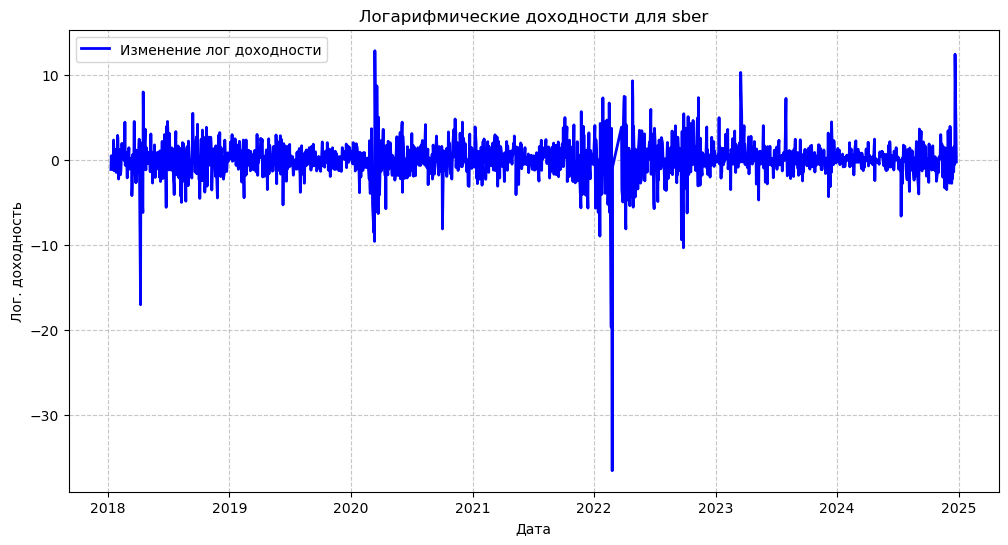

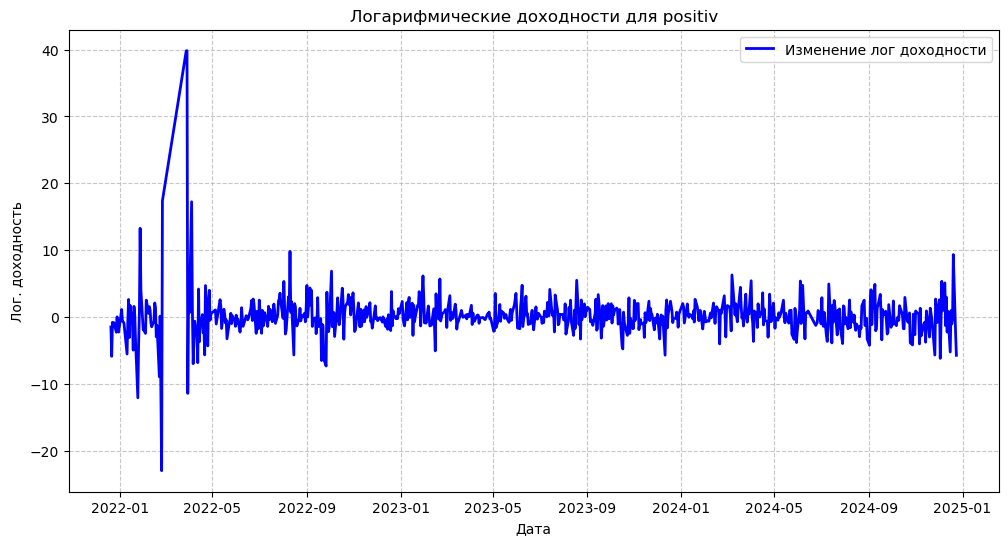

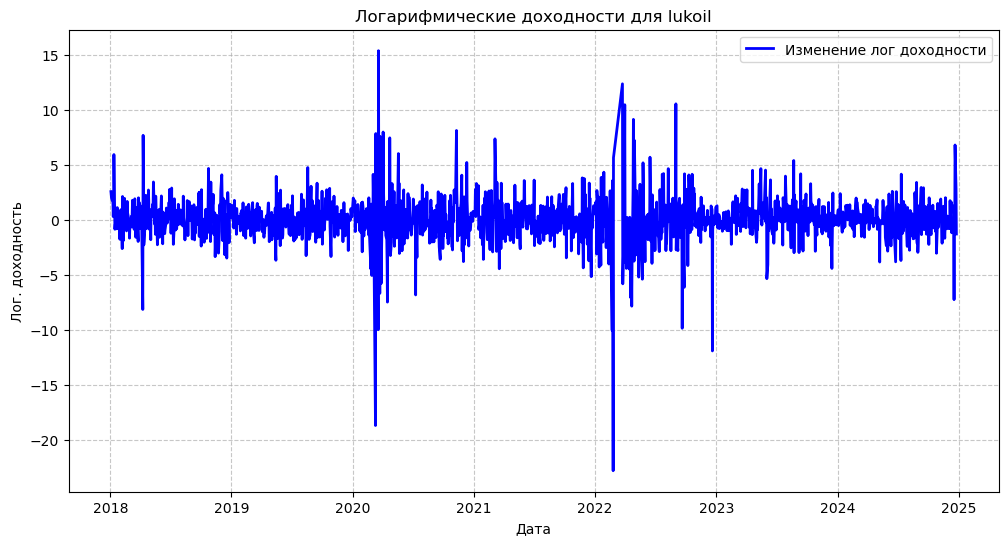

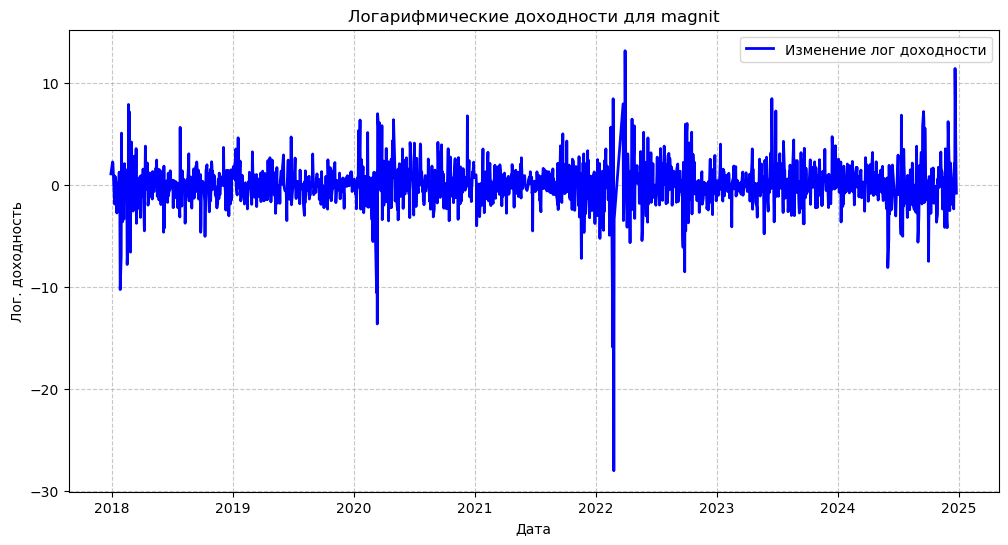

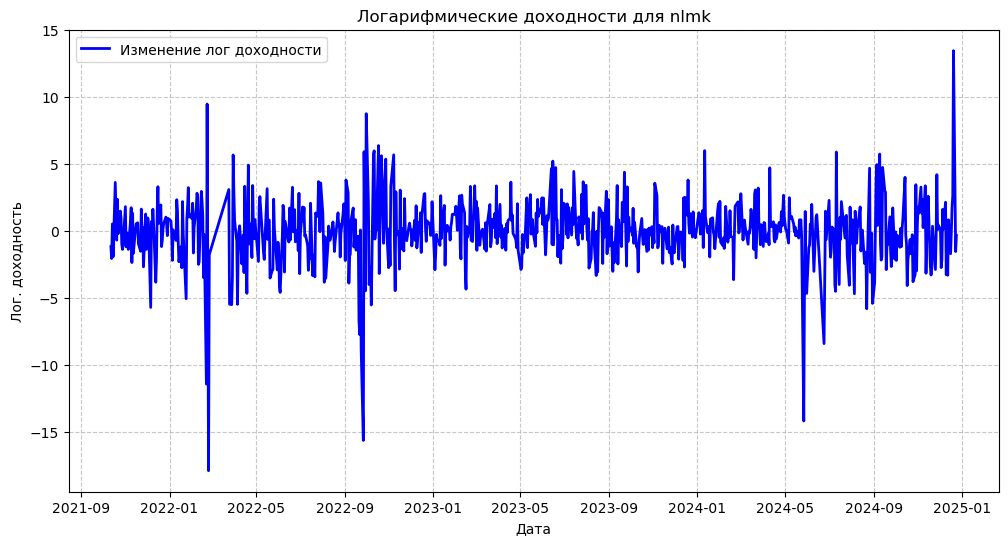

In [46]:
import matplotlib.pyplot as plt
for company in all_stocks['Company'].unique():    
    company_df = all_stocks[all_stocks['Company'] == f'{company}'].copy()
    y_company = company_df['Изм. %']
    date_company = company_df['Date']

    plt.figure(figsize=(12, 6))
    plt.plot(date_company, y_company, label= f"Изменение лог доходности", color="blue", linewidth=2)
    plt.title(f"Логарифмические доходности для {company}")
    plt.xlabel("Дата")
    plt.ylabel("Лог. доходность")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

In [225]:
over_10 = all_stocks[all_stocks['Изм. %']**2 >= 100].copy()
over_10['year_month_str'] = over_10['Date'].dt.strftime('%B-%Y')
over_10 = over_10.sort_values(by = 'Date')
over_10

,Date,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Company,year_month_str
1727,2018-01-26,5539.00,6170.00,6170.00,5531.00,"1,57M",-10.23,magnit,January-2018
1694,2018-04-09,213.00,255.05,255.30,205.00,"250,02M",-17.04,sber,April-2018
1193,2020-03-10,4549.00,5033.00,5083.00,4450.00,"7,53M",-18.65,lukoil,March-2020
1193,2020-03-10,2669.50,2686.00,2820.00,2507.00,"2,14M",-10.54,magnit,March-2020
1191,2020-03-12,2337.00,2600.00,2625.00,2313.00,"1,84M",-13.60,magnit,March-2020
1206,2020-03-13,198.60,175.00,199.52,174.30,"263,04M",12.90,sber,March-2020
1186,2020-03-19,4333.00,3830.00,4484.50,3663.00,"4,78M",15.42,lukoil,March-2020
716,2022-01-24,643.00,743.00,765.60,605.00,"71,63K",-12.09,positiv,January-2022
713,2022-01-27,700.00,618.40,760.00,618.00,"46,43K",13.27,positiv,January-2022
698,2022-02-21,4240.00,5037.50,5186.00,4021.00,"1,59M",-15.90,magnit,February-2022


In [126]:
company_colors = {
    'sber': '#006837',  
    'magnit': '#f984e5',  
    'lukoil': '#000000',  
    'positiv': '#ff0000',
    'nlmk': '#2a52be'}

In [226]:
company_colors = {
    'sber': '#72b043',  # Сбер (Зеленый)
    'nlmk': '#008585',  # НЛМК (Красный)
    'lukoil': '#eadaa0',  # ЛУКОЙЛ (Красный)
    'magnit': '#79021c',  # Магнит (Красный) # Тикер Магнита обычно MGNT
    'positiv': '#f27b50',}  # Positive Technologies (Оранжевый) # Тикер POSI

D:\Users\USER\anaconda3\envs\MachineLearning\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


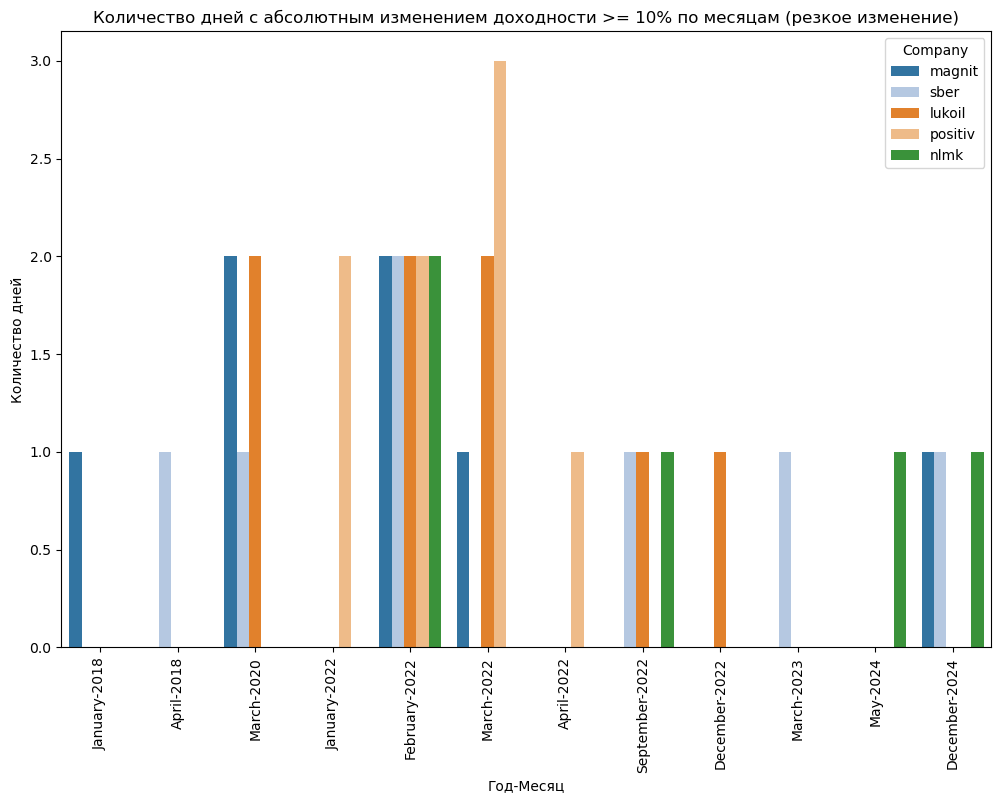

In [227]:
plt.figure(figsize = (12,8));
sns.countplot(over_10['year_month_str'], hue = over_10['Company'], palette = 'tab20');
plt.title('Количество дней с абсолютным изменением доходности >= 10% по месяцам (резкое изменение)')
plt.xlabel('Год-Месяц')
plt.ylabel('Количество дней')
plt.xticks(rotation = 90);

In [206]:
more_10 = all_stocks[all_stocks['Изм. %'] >= 10].copy()
more_10['year_month_str'] = more_10['Date'].dt.strftime('%B-%Y')
more_10 = more_10.sort_values(by = 'Date')
more_10

,Date,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Company,year_month_str
1206,2020-03-13,198.60,175.00,199.52,174.30,"263,04M",12.90,sber,March-2020
1186,2020-03-19,4333.00,3830.00,4484.50,3663.00,"4,78M",15.42,lukoil,March-2020
713,2022-01-27,700.00,618.40,760.00,618.00,"46,43K",13.27,positiv,January-2022
693,2022-02-25,560.40,481.00,599.80,481.00,"19,12K",17.39,positiv,February-2022
694,2022-03-24,5525.00,5302.50,5993.00,5300.00,"1,20M",12.41,lukoil,March-2022
692,2022-03-28,783.60,619.40,783.60,619.40,"134,81K",39.83,positiv,March-2022
691,2022-03-29,1095.80,862.00,1095.80,862.00,"327,04K",39.84,positiv,March-2022
690,2022-03-30,3855.00,3635.50,3855.00,3450.00,"207,41K",13.20,magnit,March-2022
689,2022-03-31,5680.00,5120.00,5680.00,5100.00,"469,08K",10.51,lukoil,March-2022
687,2022-04-04,1175.00,1100.00,1175.00,1012.20,"303,59K",17.24,positiv,April-2022


D:\Users\USER\anaconda3\envs\MachineLearning\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


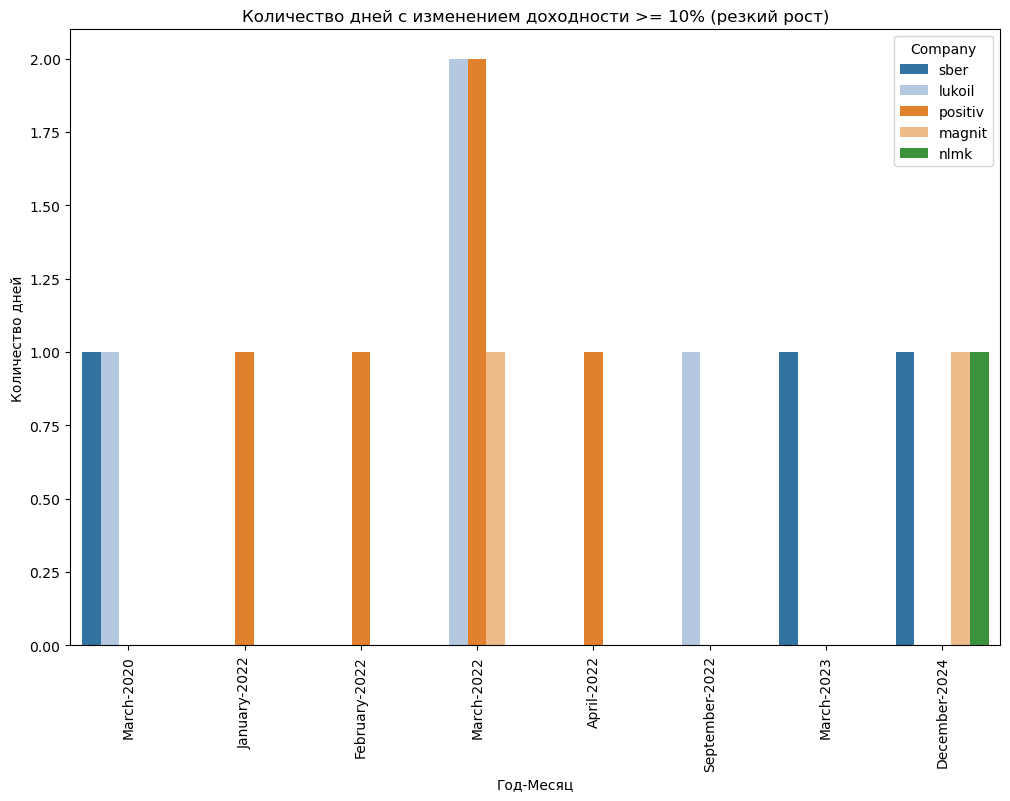

In [221]:
plt.figure(figsize = (12,8));
sns.countplot(more_10['year_month_str'], hue = more_10['Company'], palette = 'tab20');
plt.title('Количество дней с изменением доходности >= 10% (резкий рост)')
plt.xlabel('Год-Месяц')
plt.ylabel('Количество дней')
plt.xticks(rotation = 90);

In [101]:
minus_10 = all_stocks[all_stocks['Изм. %'] <= -10].copy()
minus_10['year_month_str'] = minus_10['Date'].dt.strftime('%B-%Y')
minus_10 = minus_10.sort_values(by = 'Date')
minus_10

,Date,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Company,year_month_str
1727,2018-01-26,5539.00,6170.00,6170.00,5531.00,"1,57M",-10.23,magnit,January-2018
1694,2018-04-09,213.00,255.05,255.30,205.00,"250,02M",-17.04,sber,April-2018
1193,2020-03-10,2669.50,2686.00,2820.00,2507.00,"2,14M",-10.54,magnit,March-2020
1193,2020-03-10,4549.00,5033.00,5083.00,4450.00,"7,53M",-18.65,lukoil,March-2020
1191,2020-03-12,2337.00,2600.00,2625.00,2313.00,"1,84M",-13.60,magnit,March-2020
716,2022-01-24,643.00,743.00,765.60,605.00,"71,63K",-12.09,positiv,January-2022
698,2022-02-21,5810.00,6480.00,6649.00,5609.50,"4,54M",-10.01,lukoil,February-2022
698,2022-02-21,4240.00,5037.50,5186.00,4021.00,"1,59M",-15.90,magnit,February-2022
698,2022-02-21,200.98,226.90,230.50,186.00,"36,90M",-11.42,nlmk,February-2022
714,2022-02-21,201.00,249.15,258.32,184.30,"1,08B",-19.69,sber,February-2022


D:\Users\USER\anaconda3\envs\MachineLearning\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


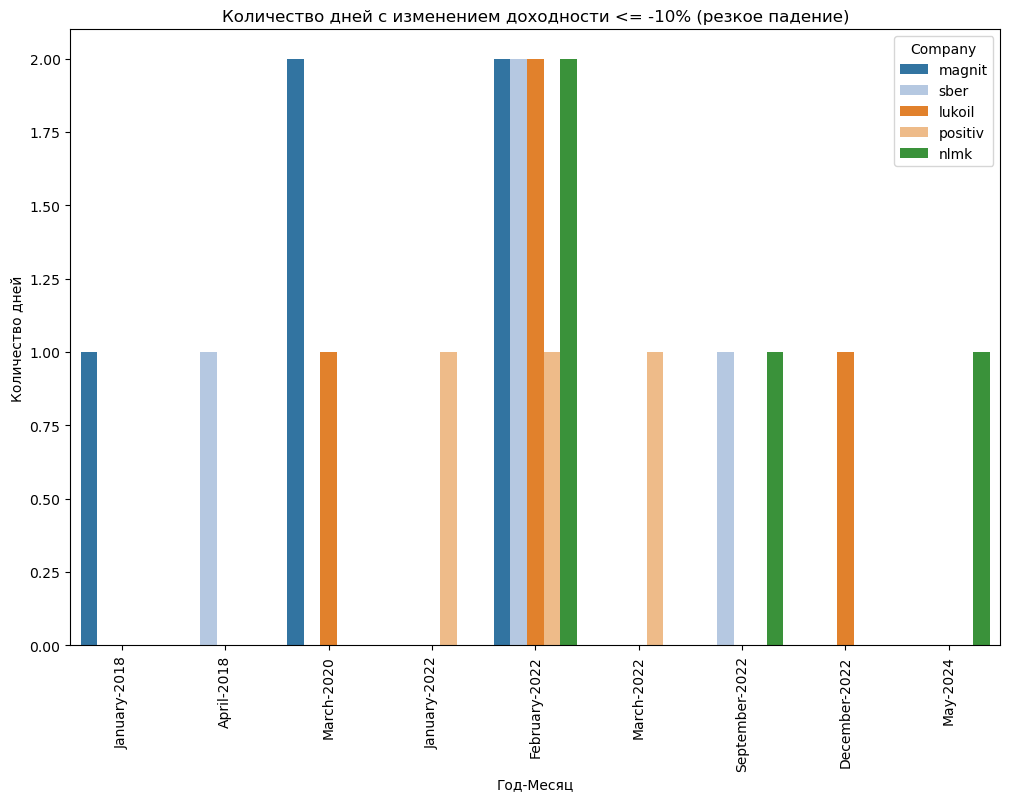

In [222]:
plt.figure(figsize = (12,8));
sns.countplot(minus_10['year_month_str'], hue = minus_10['Company'], palette = 'tab20');
plt.title('Количество дней с изменением доходности <= -10% (резкое падение)')
plt.xlabel('Год-Месяц')
plt.ylabel('Количество дней')
plt.xticks(rotation = 90);

In [ ]:
# --- Дополнительно: Построение гистограммы для визуальной оценки распределения и выбросов ---
plt.figure(figsize=(10, 5))
plt.hist(df['log_return'], bins=50, alpha=0.7, color='blue', density=True) # density=True нормирует гистограмму
plt.title(f'Гистограмма лог-доходностей {ticker}')
plt.xlabel('Лог-доходность')
plt.ylabel('Плотность вероятности')
plt.grid(True, axis='y', alpha=0.5)
plt.show()


In [ ]:
# --- Дополнительно: Ящик с усами (Box Plot) для идентификации выбросов ---
plt.figure(figsize=(6, 8))
plt.boxplot(df['log_return'])
plt.title(f'Ящик с усами для лог-доходностей {ticker}')
plt.ylabel('Лог-доходность')
plt.xticks([1], ['']) # Убираем подпись оси X
plt.grid(True, axis='y', alpha=0.5)
plt.show()


print("\nСтатистика по лог-доходностям:")
print(df['log_return'].describe())

### Объединяем датафреймы по дате и названию компании
#### how = 'outer' -> если нет новости получаем NaN значение, если нет информации по торгам, также NaN значение

In [202]:
all_merged = pd.merge(all_news, all_stocks, on = ['Date', 'Company'], how='outer')
all_merged['Date'] = all_merged['Date'].apply(lambda x: pd.to_datetime(x))

In [203]:
all_merged = all_merged.sort_values(by = 'Date', ascending = False)
all_merged.index = range(len(all_merged))

In [204]:
all_merged['Day'] = all_merged['Date'].dt.day_name()
all_merged = all_merged[['Date', 'Day', 'Company', 'Header', 'filtered_text', 'Цена', 'Откр.', 'Макс.', 'Мин.', 'Объём', 'Изм. %']]

In [205]:
all_merged

,Date,Day,Company,Header,filtered_text,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,2024-12-24,Tuesday,magnit,NaN,NaN,4945.50,4984.50,4984.50,4872.50,"504,40K",-0.77
1,2024-12-24,Tuesday,sber,NaN,NaN,264.34,264.94,266.62,261.03,"83,81M",-0.21
2,2024-12-24,Tuesday,nlmk,NaN,NaN,133.66,135.00,136.10,131.46,"9,97M",-0.33
3,2024-12-24,Tuesday,positiv,NaN,NaN,1901.00,2019.00,2011.40,1891.00,"1,08M",-5.73
4,2024-12-24,Tuesday,lukoil,NaN,NaN,6833.00,6919.00,6959.50,6825.00,"724,13K",-1.24
...,...,...,...,...,...,...,...,...,...,...,...
6835,2018-01-03,Wednesday,magnit,NaN,NaN,4985.00,4770.00,4995.00,4701.00,"900,16K",4.25
6836,2018-01-02,Tuesday,lukoil,NaN,NaN,3760.50,3733.00,3762.50,3722.50,"506,78K",0.87
6837,2018-01-02,Tuesday,magnit,Проведение заседания совета директоров (наблюд...,проведение заседание совет директор наблюдател...,5219.00,5338.00,5368.00,5174.00,"661,83K",-2.08
6838,2018-01-02,Tuesday,sber,NaN,NaN,263.20,265.00,270.30,260.60,"73,04M",-0.49


In [206]:
all_merged.to_csv('data/all_merged.csv')

In [7]:
data = pd.read_csv('data/all_merged.csv')
data

,Unnamed: 0,Date,Day,Company,Header,filtered_text,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
0,0,2024-12-24,Tuesday,magnit,NaN,NaN,4945.50,4984.50,4984.50,4872.50,"504,40K",-0.77
1,1,2024-12-24,Tuesday,sber,NaN,NaN,264.34,264.94,266.62,261.03,"83,81M",-0.21
2,2,2024-12-24,Tuesday,nlmk,NaN,NaN,133.66,135.00,136.10,131.46,"9,97M",-0.33
3,3,2024-12-24,Tuesday,positiv,NaN,NaN,1901.00,2019.00,2011.40,1891.00,"1,08M",-5.73
4,4,2024-12-24,Tuesday,lukoil,NaN,NaN,6833.00,6919.00,6959.50,6825.00,"724,13K",-1.24
...,...,...,...,...,...,...,...,...,...,...,...,...
6835,6835,2018-01-03,Wednesday,magnit,NaN,NaN,4985.00,4770.00,4995.00,4701.00,"900,16K",4.25
6836,6836,2018-01-02,Tuesday,lukoil,NaN,NaN,3760.50,3733.00,3762.50,3722.50,"506,78K",0.87
6837,6837,2018-01-02,Tuesday,magnit,Проведение заседания совета директоров (наблюд...,проведение заседание совет директор наблюдател...,5219.00,5338.00,5368.00,5174.00,"661,83K",-2.08
6838,6838,2018-01-02,Tuesday,sber,NaN,NaN,263.20,265.00,270.30,260.60,"73,04M",-0.49


In [14]:
data['Date'] = (pd.to_datetime(data['Date']))

In [16]:
data[data['Date'] == '2018-01-11']

,Unnamed: 0,Date,Day,Company,Header,filtered_text,Цена,Откр.,Макс.,Мин.,Объём,Изм. %
6821,6821,2018-01-11,Thursday,lukoil,"Сведения, направленные за пределы РФ для их ра...",направлять предоставлять соответствовать иност...,4937.00,4910.0,5004.00,4861.5,"695,20K",-0.16
6822,6822,2018-01-11,Thursday,sber,"Сведения, оказывающие, по мнению эмитента, сущ...",оказывать стоимость эмиссионный сбербанк росси...,188.67,189.5,191.36,186.7,"77,59M",-0.60
6823,6823,2018-01-11,Thursday,magnit,"Сведения, направленные за пределы РФ для их ра...",cообщение направлять предоставлять соответство...,3640.00,3630.0,3648.00,3603.5,"412,04K",1.39


### Добавим изменение логарифмической доходности с лагом в 1,2,3 дня
#### Также мы поочередно в новый датафрейм добавили упорядоченные по времени данные о каждой из компаний, чтобы не обучать 5 моделей для каждой компании

In [288]:
final_df = pd.DataFrame()
for company in all_merged['Company'].unique():    
    company_df = all_merged[all_merged['Company'] == f'{company}'].copy()
    company_df['Изменение с лагом в 3 дня %'] = (np.log(company_df['Цена'].shift(3) / company_df['Цена'])) * 100
    company_df['Изменение с лагом в 2 дня %'] = (np.log(company_df['Цена'].shift(2) / company_df['Цена'])) * 100
    company_df['Изменение с лагом в 1 день %'] = (np.log(company_df['Цена'].shift(1) / company_df['Цена'])) * 100
    final_df = pd.concat([final_df, company_df], ignore_index=True)
final_df

,Date,Day,Company,Header,filtered_text,Цена,Откр.,Макс.,Мин.,Объём,Изм. %,Изменение с лагом в 3 дня %,Изменение с лагом в 2 дня %,Изменение с лагом в 1 день %
0,2024-12-24,Tuesday,magnit,NaN,NaN,4945.5,4984.5,4984.5,4872.5,"504,40K",-0.77,NaN,NaN,NaN
1,2024-12-23,Monday,magnit,Приобретение подконтрольной эмитенту организац...,приобретение голосовать акция доля депозитарны...,4984.0,4991.5,5081.0,4926.0,"753,38K",1.27,NaN,NaN,-0.775471
2,2024-12-20,Friday,magnit,NaN,NaN,4921.5,4398.0,4923.0,4376.0,"1,08M",11.46,NaN,0.486471,1.261942
3,2024-12-19,Thursday,magnit,"Выплаченные доходы или иные выплаты, причитающ...",выплатить доход также выплата причитаться влад...,4415.5,4452.0,4521.5,4407.0,"451,74K",-0.38,11.335699,12.111170,10.849228
4,2024-12-18,Wednesday,magnit,NaN,NaN,4432.5,4350.0,4466.5,4301.0,"398,91K",2.13,11.726902,10.464960,-0.384268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6835,2018-01-10,Wednesday,lukoil,NaN,NaN,5016.0,5045.0,5115.0,4980.0,"944,92K",-0.12,-26.144762,-25.770012,-1.587494
6836,2018-01-08,Monday,lukoil,NaN,NaN,4494.0,4460.0,4509.0,4454.5,"513,11K",0.95,-14.781049,9.401469,10.988963
6837,2018-01-06,Saturday,lukoil,"Сведения, направленные за пределы РФ для их ра...",направлять предоставлять соответствовать иност...,4205.5,4210.0,4258.0,4180.5,"750,95K",-0.08,16.036467,17.623961,6.634998
6838,2018-01-03,Wednesday,lukoil,"Сведения, направленные за пределы РФ для их ра...",направлять предоставлять соответствовать иност...,3754.0,3767.5,3790.0,3741.0,"581,00K",-0.60,28.981087,17.992124,11.357125


In [289]:
final_df.to_csv('data/final_df.csv')

### Датасет для регрессии Random Forest

Ноутбук `regression_random_forest.ipynb` читает `data/merged_news.csv` с колонкой `log_1` (лог-доходность на 1 день вперёд).


In [ ]:
merged_news = all_merged.copy()
merged_news['Date'] = pd.to_datetime(merged_news['Date'])
merged_news = merged_news.sort_values(['Company', 'Date'])
merged_news['log_1'] = merged_news.groupby('Company')['Цена'].transform(
    lambda s: np.log(s.shift(-1) / s)
)
company_names = {
    'sber': 'Sber',
    'lukoil': 'Lukoil',
    'magnit': 'Magnit',
    'nlmk': 'Nlmk',
    'positiv': 'Positiv',
}
merged_news['Company'] = merged_news['Company'].map(company_names).fillna(merged_news['Company'])
merged_news.to_csv('data/merged_news.csv', index=False)
merged_news.head()


In [3]:
df = pd.read_csv('data/final_df.csv')

In [16]:
pd.DataFrame([df['Date'], df['Цена'], df['Цена'].shift(2), np.log(df['Цена'].shift(2)/df['Цена'])]).transpose()

,Date,Цена,Цена,Цена
0,2024-12-24,4945.5,NaN,NaN
1,2024-12-23,4984,NaN,NaN
2,2024-12-20,4921.5,4945.5,0.00486471
3,2024-12-19,4415.5,4984,0.121112
4,2024-12-18,4432.5,4921.5,0.10465
...,...,...,...,...
6835,2018-01-10,5016,3876.5,-0.2577
6836,2018-01-08,4494,4937,0.0940147
6837,2018-01-06,4205.5,5016,0.17624
6838,2018-01-03,3754,4494,0.179921


In [15]:
np.log(4945.5/4921.5)

0.004864710110629361